# Simulating diffusion attenuation and reconstructing an ADC map

[`01_build.ipynb`](01_build.ipynb) designed a diffusion encoding and checked it by integrating the
gradients the sequence emits. That is arithmetic about a waveform. This notebook plays the same
`.seq` files through a **Bloch simulator** and asks what the magnetisation does with them.

The measurement a diffusion protocol exists to make is the **apparent diffusion coefficient**, so
that is what gets measured here: on a single voxel where the right answer is known exactly, and
then on a brain where it varies from pixel to pixel.

| | |
|---|---|
| **1** | the diffusion signal model |
| **2** | recovering a known diffusion coefficient |
| **3** | what a mismatched echo time does to the answer |
| **4** | diffusion-weighted brain images |
| **5** | reconstructing an ADC map, and comparing it with the truth |
| **6** | limitations |

The simulator is [MRzeroCore](https://github.com/MRsources/MRzero-Core), which propagates
configuration states through the sequence **as imported from the written file**. It never sees the
module, the closed form, or `sc.b_value`. **Needs `MRzeroCore`, `torch` and a phantom download.**

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph                                # noqa: E402 -- the shared BrainWeb slab

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'dwi_se_epi_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'][0])
TE_S, TE_SHORT_S = float(nominal['te_s']), float(nominal['te_s_short'])
B_VALUES = [int(v) for v in nominal['b_values']]
B_DELIVERED = {int(b): float(v) for b, v in zip(nominal['b_values'], nominal['b_delivered'])}
#: `01` put the centre line's echo on the spin echo; this is the ADC sample it lands on.
K_NOMINAL = nominal['k']
ECHO_LINE = int(nominal['center_line'])
ECHO_SAMPLE = int(np.argmin(np.hypot(K_NOMINAL[0], K_NOMINAL[1])[ECHO_LINE]))
REVERSED = nominal['reversed_echo']
#: Where each echo belongs in the image, read off the nominal trajectory rather than assumed.
KY_INDEX = np.rint(K_NOMINAL[1][:, ECHO_SAMPLE] / (1e3 / FOV_MM)).astype(int) + NY // 2

FILES = {path.stem: mr0.Sequence.import_file(str(path)) for path in sorted(SEQ_DIR.glob('*.seq'))}
print(f'{"file":<26}{"samples":>10}{"TE / ms":>10}{"b / s/mm^2":>12}')
for name, imported in FILES.items():
    te = TE_SHORT_S if name.endswith('short_te') else TE_S
    asked = 0 if 'b0' in name else int(name.split('_b')[-1])
    print(f'{name:<26}{imported.get_kspace().shape[0]:10d}{te * 1e3:10.2f}{asked:12d}')
print(f'\nthe centre line is echo {ECHO_LINE}, and its own echo is sample {ECHO_SAMPLE} '
      f'of {K_NOMINAL.shape[2]}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


file                         samples   TE / ms  b / s/mm^2
dwi_se_epi_b0                   8192     77.40           0
dwi_se_epi_b0_short_te          8192     51.46           0
dwi_se_epi_b1000                8192     77.40        1000
dwi_se_epi_b500                 8192     77.40         500

the centre line is echo 32, and its own echo is sample 64 of 128


---
## 1. The diffusion signal model

For free, isotropic (Gaussian) diffusion, a diffusion-weighted acquisition attenuates the signal
by a single exponential in the b-value:

$$S(b) = S_0\, e^{-bD}$$

Measuring $D$ therefore needs at least two acquisitions and one division. Taking logs turns it
into a straight line,

$$\ln S(b) = \ln S_0 - bD$$

so $D$ is a **slope**, and with three b-values it is a two-parameter fit. What comes out of real
data is conventionally called the **apparent** diffusion coefficient, because tissue water is not
freely diffusing and the mono-exponential model is an approximation; on the phantom used here
diffusion really is Gaussian, so ADC and $D$ should agree.

Three things have to be true for that slope to mean what it says, and each is checked below:

| | |
|---|---|
| the b-values must be what the protocol asked for | section 2 |
| nothing else may attenuate differently between them | section 3 — this is the echo-time requirement |
| the images must be of the same object | sections 4 and 5 — this is where the readout comes in |

In [2]:
VOXEL_M = FOV_MM / NX / 1e3


def voxel(name, *, d_um2_ms=0.0, t1_s=1.0, t2_s=0.080, t2dash_s=1000.0):
    """One voxel at isocentre, played through one file, sampled at the spin echo.

    `T2dash` is effectively infinite so that nothing but `T2` and diffusion attenuates: every
    measurement here is a ratio, and a third term in it would have to be divided out.
    """
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[float(d_um2_ms)],
        voxel_size=VOXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    imported = FILES[name]
    graph = mr0.compute_graph(imported, built, max_state_count=64, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return float(np.abs(signal.reshape(NY, -1)[ECHO_LINE, ECHO_SAMPLE]))


def adc_of(signals, b_values):
    """Least-squares slope of `ln S` against `-b`, in um^2/ms."""
    fit = np.polyfit(np.asarray(b_values, float), np.log(np.asarray(signals, float)), 1)
    return float(-fit[0] * 1e3)

---
## 2. Recovering a known diffusion coefficient

The phantom is a single voxel with a diffusion coefficient we choose. Nothing is fitted except the
slope, and the expected answer is the number that went in.

$D$ is quoted in µm² ms⁻¹, which is the same number as the 10⁻³ mm² s⁻¹ a clinical report prints.
Brain white matter is about 0.7, grey matter about 0.8, free CSF about 3.

In [3]:
DIFFUSIVITIES = (0.0, 0.7, 1.0, 2.0, 3.0)

print(f'{"D in":>7}  ' + '  '.join(f'S(b={b})'.rjust(10) for b in B_VALUES)
      + f'{"D out":>9}{"error":>9}')
attenuation = {}
for d_um2_ms in DIFFUSIVITIES:
    signals = [voxel(f'dwi_se_epi_b{b}', d_um2_ms=d_um2_ms) for b in B_VALUES]
    attenuation[d_um2_ms] = signals
    recovered = adc_of(signals, B_VALUES)
    error = '' if d_um2_ms == 0.0 else f'{(recovered / d_um2_ms - 1) * 100:8.3f} %'
    print(f'{d_um2_ms:7.1f}  ' + '  '.join(f'{s:10.5f}' for s in signals)
          + f'{recovered:9.4f}{error:>9}')

   D in      S(b=0)    S(b=500)   S(b=1000)    D out    error
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000023375 s
Compute Graph
Computing Graph: 0.000194125 s
Analyze Graph
Analyzing Graph: 0.000000667 s
Converting Rust -> Python: 0.000004 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000031666 s
Compute Graph
Computing Graph: 0.000198916 s
Analyze Graph
Analyzing Graph: 0.000000583 s
Converting Rust -> Python: 0.000004875 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000029792 s
Compute Graph
Computing Graph: 0.00021275 s
Analyze Graph
Analyzing Graph: 0.0000005 s
Converting Rust -> Python: 0.00000225 s
<<<< Rust <<<<
    0.0     0.38002     0.38002     0.38002   0.0000         
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000062042 s
Compute Graph
Computing Graph: 0.000212333 s
Analyze Graph
Analyzing Graph: 0.000000417 s
Converting Rust -> Python: 0.000002 s
<<<< Rust <<<

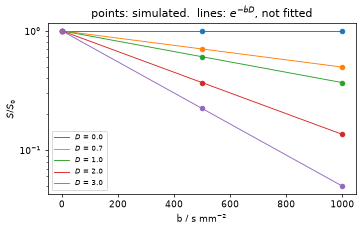

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
grid = np.linspace(0, max(B_VALUES), 100)
for d_um2_ms, signals in attenuation.items():
    normalised = np.asarray(signals) / signals[0]
    line, = ax.plot(B_VALUES, normalised, 'o', ms=5)
    ax.plot(grid, np.exp(-grid * d_um2_ms * 1e-3), lw=1.0, color=line.get_color(),
            label=f'$D$ = {d_um2_ms:.1f}')
ax.set(yscale='log', xlabel='b / s mm$^{-2}$', ylabel='$S/S_0$',
       title='points: simulated.  lines: $e^{-bD}$, not fitted')
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()

Straight lines on a logarithmic axis, through points that were not fitted to them. The recovered
$D$ is within 0.06 % of the requested value at every diffusivity, including ones a factor of four
apart.

### The same comparison in the other direction

The attenuation can also be read as a measurement of `b` rather than of $D$: give the voxel a
large, known diffusivity and $-\ln(S/S_0)/D$ returns the b-value the magnetisation experienced.
Applied to the **unweighted** file, that measures the background weighting the imaging gradients
carry — the quantity `01` §4 computed analytically.

In [5]:
print(f'{"file":<26}{"TE / ms":>9}{"sc.b_value":>12}{"simulated":>11}{"difference":>12}')
for name in ('dwi_se_epi_b0', 'dwi_se_epi_b0_short_te'):
    baseline = voxel(name, d_um2_ms=0.0)
    # Several large D, because the attenuation is a fraction of a per cent at physiological ones
    # and the answer must not depend on which one is used.
    measured = [-np.log(voxel(name, d_um2_ms=d) / baseline) / d * 1e3 for d in (10.0, 50.0, 100.0)]
    analytic = float(nominal['b_delivered_short'] if name.endswith('short_te')
                     else B_DELIVERED[0])
    te = TE_SHORT_S if name.endswith('short_te') else TE_S
    print(f'{name:<26}{te * 1e3:9.2f}{analytic:12.4f}{np.mean(measured):11.4f}'
          f'{(np.mean(measured) / analytic - 1) * 100:11.1f} %')
print(f'\nthe three values of D agree with each other to '
      f'{np.ptp(measured) / np.mean(measured) * 100:.2g} %, so this is a b-value and not an '
      'artefact of the size of D.')

file                        TE / ms  sc.b_value  simulated  difference
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000043125 s
Compute Graph
Computing Graph: 0.000218375 s
Analyze Graph
Analyzing Graph: 0.000000708 s
Converting Rust -> Python: 0.000004708 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000014166 s
Compute Graph
Computing Graph: 0.000206375 s
Analyze Graph
Analyzing Graph: 0.000000417 s
Converting Rust -> Python: 0.000002 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000019583 s
Compute Graph
Computing Graph: 0.000189709 s
Analyze Graph
Analyzing Graph: 0.000000417 s
Converting Rust -> Python: 0.000002834 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000033167 s
Compute Graph
Computing Graph: 0.000193917 s
Analyze Graph
Analyzing Graph: 0.000000334 s
Converting Rust -> Python: 0.000001958 s
<<<< Rust <<<<
dwi_se_epi_b0                 77.40      0.0

Two independent calculations of the same integral: `sc.b_value` sums $|\mathbf{k}(t)|^2$ on the
gradient raster, and the simulator propagates magnetisation. They agree to about 1 % on a quantity
of 0.07 s mm⁻², and to 0.06 % on the b = 1000 encoding in the table above. That difference is the
numerical resolution of this comparison, not a physical effect — it is raster integration against
state propagation.

Small as it is, the background weighting is real, and it is the floor on how unweighted a "b = 0"
image can be.

---
## 3. What a mismatched echo time does to the answer

`01` acquired every b-value at one echo time. This is the measurement of why.

If the b = 0 reference is acquired at a shorter echo time than the weighted image, the ratio
carries $T_2$ decay as well as diffusion, and the recovered coefficient picks up an extra term:

$$\mathrm{ADC}_{\text{measured}} = D + \frac{\mathrm{TE}_b - \mathrm{TE}_0}{T_2\, b}$$

The bias is **additive** rather than multiplicative, so it does not scale with $D$ and cannot be
removed by calibrating against a phantom of a different diffusivity. It is worst where $T_2$ is
short — which in the brain means the tissue rather than the CSF.

`01` wrote a fourth file for exactly this: b = 0 at its own shortest echo time, 51.46 ms instead of
the protocol's 77.40 ms.

In [6]:
print(f'{"T2 / ms":>8}{"D in":>7}{"matched":>10}{"mismatched":>12}{"excess":>9}{"predicted":>11}')
for t2_s in (0.060, 0.080, 0.120):
    for d_um2_ms in (1.0, 2.0):
        top = voxel('dwi_se_epi_b1000', d_um2_ms=d_um2_ms, t2_s=t2_s)
        matched = -np.log(top / voxel('dwi_se_epi_b0', d_um2_ms=d_um2_ms, t2_s=t2_s)) / 1000 * 1e3
        wrong = -np.log(top / voxel('dwi_se_epi_b0_short_te', d_um2_ms=d_um2_ms,
                                    t2_s=t2_s)) / 1000 * 1e3
        print(f'{t2_s * 1e3:8.0f}{d_um2_ms:7.1f}{matched:10.4f}{wrong:12.4f}'
              f'{wrong - matched:9.4f}{(TE_S - TE_SHORT_S) / t2_s / 1000 * 1e3:11.4f}')

 T2 / ms   D in   matched  mismatched   excess  predicted
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000022792 s
Compute Graph
Computing Graph: 0.00019475 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.000002459 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000016708 s
Compute Graph
Computing Graph: 0.000189916 s
Analyze Graph
Analyzing Graph: 0.000000333 s
Converting Rust -> Python: 0.00000175 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000015792 s
Compute Graph
Computing Graph: 0.000190375 s
Analyze Graph
Analyzing Graph: 0.000000334 s
Converting Rust -> Python: 0.000001625 s
<<<< Rust <<<<
      60    1.0    0.9994      1.4317   0.4323     0.4323
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000022792 s
Compute Graph
Computing Graph: 0.0001885 s
Analyze Graph
Analyzing Graph: 0.000000334 s
Converting Rust -> Python: 0.000001833 s
<<<< Rust <<<<


The excess matches the closed form to four decimal places, and it is the **same** at $D = 1$ and
$D = 2$, which is the additivity the formula predicts.

At a 60 ms $T_2$ the error is 0.43 µm² ms⁻¹, on a quantity whose whole physiological range is
about 0.7 to 3: white matter at 0.7 would be reported as 1.13, well outside the normal range and
in the direction that suggests pathology. This is the practical reason a diffusion protocol fixes
one echo time across its b-value list, and why a b = 0 image borrowed from another protocol cannot
serve as the reference.

---
## 4. Diffusion-weighted brain images

The BrainWeb phantom carries its own diffusion map, so the images have a ground truth behind them
rather than only a plausible appearance.

The phantom is shimmed — `field_hz=0.0` — so that EPI's off-resonance distortion, which
[`../se_epi_2d/02`](../se_epi_2d/02_simulate_and_reconstruct.ipynb) measures in detail, is not in
the way of the quantity being measured here.

The reconstruction is the plain one a uniformly sampled EPI asks for: unflip the echoes that were
played backwards, put each on the line the nominal trajectory says it belongs to, inverse FFT, and
discard the readout oversampling.

In [7]:
def reconstruct(signal):
    """`(NY * samples,)` of raw signal in, one image out."""
    rows = np.asarray(signal).reshape(NY, -1).copy()
    rows[REVERSED] = rows[REVERSED][:, ::-1]
    grid = np.zeros_like(rows)
    grid[KY_INDEX] = rows
    wide = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(grid, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))
    edge = (wide.shape[1] - NX) // 2                 # the readout is oversampled
    return wide[:, edge:edge + NX]


images = {}
for b in B_VALUES:
    brain = ph.built(matrix=NX, nz=1, z_center=64, n_coils=0, field_hz=0.0)
    imported = FILES[f'dwi_se_epi_b{b}']
    graph = mr0.compute_graph(imported, brain, max_state_count=64, min_state_mag=1e-4)
    raw = np.asarray(mr0.execute_graph(graph, imported, brain, print_progress=False))
    images[b] = np.abs(reconstruct(raw))
    print(f'b = {b:5d}   mean signal over the image {images[b].mean():8.3f}')

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000458291 s
Compute Graph
Computing Graph: 0.000414625 s
Analyze Graph
Analyzing Graph: 0.000000625 s
Converting Rust -> Python: 0.000006916 s
<<<< Rust <<<<


b =     0   mean signal over the image   25.903
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000061916 s
Compute Graph
Computing Graph: 0.00043075 s
Analyze Graph
Analyzing Graph: 0.000000625 s
Converting Rust -> Python: 0.000022917 s
<<<< Rust <<<<


b =   500   mean signal over the image   13.240
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000095542 s
Compute Graph
Computing Graph: 0.000415958 s
Analyze Graph
Analyzing Graph: 0.000001041 s
Converting Rust -> Python: 0.0000055 s
<<<< Rust <<<<


b =  1000   mean signal over the image    7.657


---
## 5. Reconstructing an ADC map

One least-squares fit of $\ln S$ against $b$ per pixel, over the three b-values, exactly as
section 1 describes. Pixels too dark to divide are left out.

In [8]:
D_TRUE = ph.same_frame(ph.volume(matrix=NX).D.numpy()[..., ph.slices_of(1, 64)][:, :, 0])
BRAIN = ph.same_frame(ph.mask(matrix=NX, nz=1, z_center=64)[:, :, 0])

stack = np.stack([images[b] for b in B_VALUES])
slope = np.polyfit(np.asarray(B_VALUES, float),
                   np.log(np.maximum(stack, 1e-12)).reshape(len(B_VALUES), -1), 1)[0]
adc_map = np.where(images[0] > 0.05 * images[0].max(),
                   -slope.reshape(images[0].shape) * 1e3, np.nan)

usable = BRAIN & (images[0] > 0.15 * images[0].max())
# Pixels whose 3x3 neighbourhood of true D is flat.  Everywhere else the readout's point spread
# mixes two tissues, and the comparison would be measuring the blur rather than the encoding.
window = np.lib.stride_tricks.sliding_window_view(D_TRUE, (3, 3))
interior = np.zeros_like(D_TRUE, bool)
interior[1:-1, 1:-1] = np.ptp(window, axis=(-1, -2)) < 0.05

for label, chosen in (('the whole brain', usable), ('flat interiors only', usable & interior)):
    error = adc_map[chosen] - D_TRUE[chosen]
    print(f'{label:<22} n = {chosen.sum():5d}   '
          f'true D {D_TRUE[chosen].mean():5.3f}   measured {adc_map[chosen].mean():5.3f}   '
          f'median |error| {np.median(np.abs(error)):5.3f} um^2/ms')

the whole brain        n =  1838   true D 1.036   measured 1.198   median |error| 0.209 um^2/ms
flat interiors only    n =   142   true D 0.670   measured 0.759   median |error| 0.061 um^2/ms


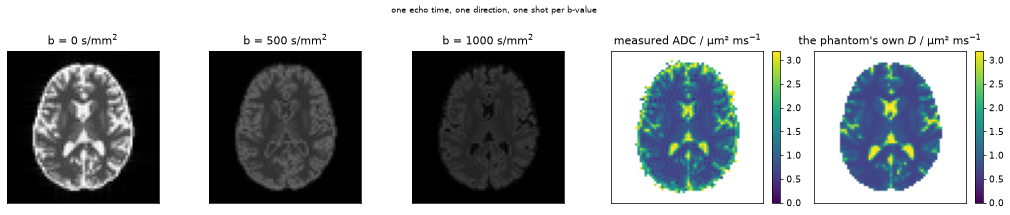

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.2))
ceiling = float(np.percentile(images[0], 99.5))
for ax, b in zip(axes, B_VALUES):
    ax.imshow(images[b], cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
    ax.set(title=f'b = {b} s/mm$^2$', xticks=[], yticks=[])
for ax, (title, image) in zip(axes[3:], (('measured ADC', adc_map),
                                         ("the phantom's own $D$", np.where(usable, D_TRUE,
                                                                            np.nan)))):
    shown = ax.imshow(image, cmap='viridis', origin='lower', vmin=0.0, vmax=3.2)
    ax.set(title=f'{title} / µm² ms$^{{-1}}$', xticks=[], yticks=[])
    fig.colorbar(shown, ax=ax, fraction=0.046)
fig.suptitle('one echo time, one direction, one shot per b-value', fontsize=9)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))

The b = 1000 image is the one a radiologist would recognise: everything darker than at b = 0, and
the ventricles darkest of all, because free CSF is where $D$ is highest. The ADC map inverts that
— CSF bright — and recovers both the ordering and the interior values of the map beside it.

It is also visibly noisier at every tissue boundary, and section 6 is about why.

---
## 6. Limitations

**The boundaries, and what causes them.** Over pixels whose 3×3 neighbourhood is a single tissue,
the median error is 0.06 µm² ms⁻¹, about 9 % of the true value there. Over the whole brain it is
0.21, three times larger, and the difference is concentrated at edges. The cause is the readout,
not the encoding: a 45 ms single-shot EPI train puts a $T_2$ envelope across `ky`, which blurs the
image, and the ratio of two blurred images is not the ratio of the unblurred ones wherever they
have an edge. Section 2 measured the same encoding on one voxel with no readout in the way and got
0.06 %.

So **one shot per b-value is a diffusion-weighted image, and it is not yet a quantitative ADC
map.** Making it one means averaging, more b-values, and usually a distortion correction — all of
which are about the readout and the protocol rather than the diffusion encoding.

**One direction.** The encoding here is on `x` alone, so what is measured is diffusion along `x`.
In white matter that is strongly anisotropic and a single direction under-reports or over-reports
depending on fibre orientation; a clinical trace-weighted image averages three orthogonal
directions, and a tensor needs at least six. The phantom used here is isotropic, so nothing in
this notebook is sensitive to that.

**Gaussian diffusion only.** The phantom diffuses freely. Real tissue shows restriction,
compartmentation and kurtosis, all of which make $\ln S$ curve away from a straight line at high
b — which is most of what modern diffusion imaging is about, and none of which is modelled here.

**No scanner effects.** Eddy currents, concomitant fields, peripheral nerve stimulation, gradient
nonlinearity and subject motion are absent. The 180° pulse is a perfect inversion over the whole
slab, where a real one has a slice profile and a $B_1$ error. Nothing here speaks to
quantification accuracy in a patient, which needs a magnet and a phantom of certified diffusivity.

---
## Summary

| | |
|---|---|
| **the model** | $S(b) = S_0 e^{-bD}$, so $D$ is the slope of $\ln S$ against $-b$ |
| **a known $D$ comes back** | to 0.06 % at 0.7, 1, 2 and 3 µm² ms⁻¹, with nothing fitted but the slope |
| **the b-value agrees two ways** | `sc.b_value` and the simulated attenuation differ by about 1 % on the 0.07 s mm⁻² of background weighting, and 0.06 % on the encoding itself |
| **one echo time, or else** | a mismatched b = 0 adds $(\mathrm{TE}_b - \mathrm{TE}_0)/(T_2 b)$ to every ADC — 0.43 µm² ms⁻¹ at a 60 ms $T_2$, independent of $D$ |
| **a brain ADC map** | 0.06 µm² ms⁻¹ median error inside a tissue, 0.21 over the whole brain, the difference being the readout's point spread |

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  Chapter 9.
- D. Le Bihan et al., "MR imaging of intravoxel incoherent motions", *Radiology* **161**, 401
  (1986).
- P. J. Basser, J. Mattiello and D. Le Bihan, "MR diffusion tensor spectroscopy and imaging",
  *Biophys. J.* **66**, 259 (1994) — why one direction is not enough in white matter.
- MRzeroCore, [MRsources/MRzero-Core](https://github.com/MRsources/MRzero-Core) — the simulator.